In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('/Users/wenduom/Desktop/ml/ml2026/makemore/names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)               
print(len(itos))

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size = 6

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            i = stoi[c]
            X.append(context)
            Y.append(i)        
            #print(''.join([itos[ii] for ii in context]) + ' --> ' + itos[i])
            context = context[1:] + [i]
                    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

    
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 6]) torch.Size([182625])
torch.Size([22655, 6]) torch.Size([22655])
torch.Size([22866, 6]) torch.Size([22866])


In [36]:
g = torch.Generator().manual_seed(2147483647) 

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out


    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


        
                
        
n_embed = 10
n_hidden = 100
vocab_size = 27

C = torch.randn((vocab_size, n_embed), generator=g)

layers = [
    Linear(n_embed * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),   Tanh(),
    Linear(n_hidden, n_hidden),   Tanh(),
    Linear(n_hidden, n_hidden),   Tanh(),
    Linear(n_hidden, n_hidden),   Tanh(),
    Linear(n_hidden, vocab_size),
]


with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1

    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True
            

49497


In [47]:
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    xb, yb = Xtr[ix], Ytr[ix]

    emb = C[xb]
    x = emb.view(-1, block_size*n_embed)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)


    #back pass
    for layer in layers:
        layer.out.retain_grad() # retain grad for tanh
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())    

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break
    
    
    

      0/ 200000: 3.1882


layer 1 (      Tanh): mean -0.03, std 0.74, saturated: 18.06%
layer 3 (      Tanh): mean +0.01, std 0.72, saturated: 12.25%
layer 5 (      Tanh): mean +0.03, std 0.72, saturated: 11.25%
layer 7 (      Tanh): mean -0.03, std 0.74, saturated: 11.66%
layer 9 (      Tanh): mean -0.04, std 0.72, saturated: 13.03%


Text(0.5, 1.0, 'activation distribution')

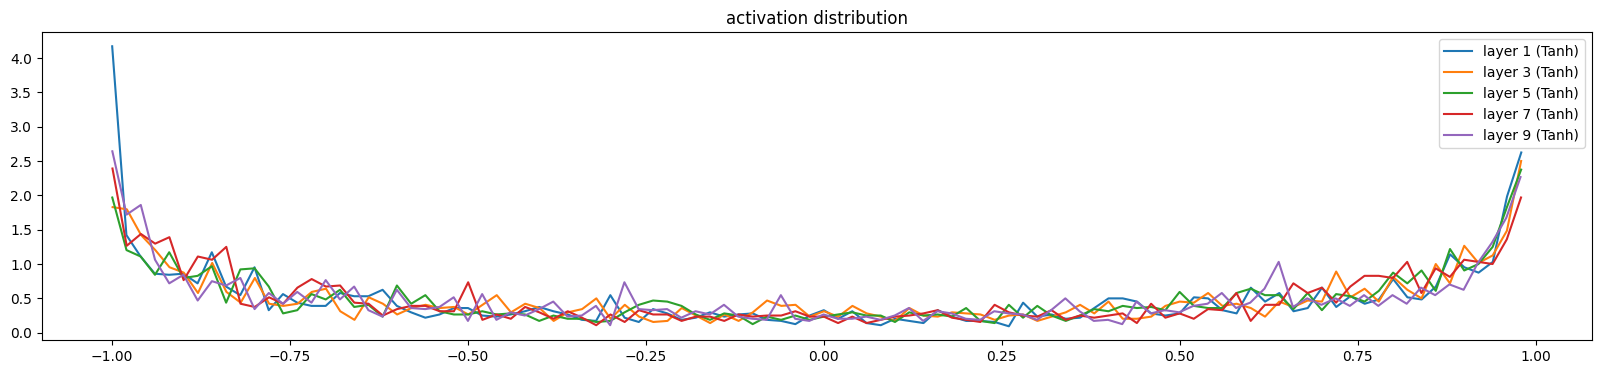

In [48]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
        
plt.legend(legends)
plt.title('activation distribution')


layer 1 (      Tanh): mean +0.00, std 0.00
layer 3 (      Tanh): mean +0.00, std 0.00
layer 5 (      Tanh): mean +0.00, std 0.00
layer 7 (      Tanh): mean +0.00, std 0.00
layer 9 (      Tanh): mean +0.00, std 0.00


Text(0.5, 1.0, 'gradient distribution')

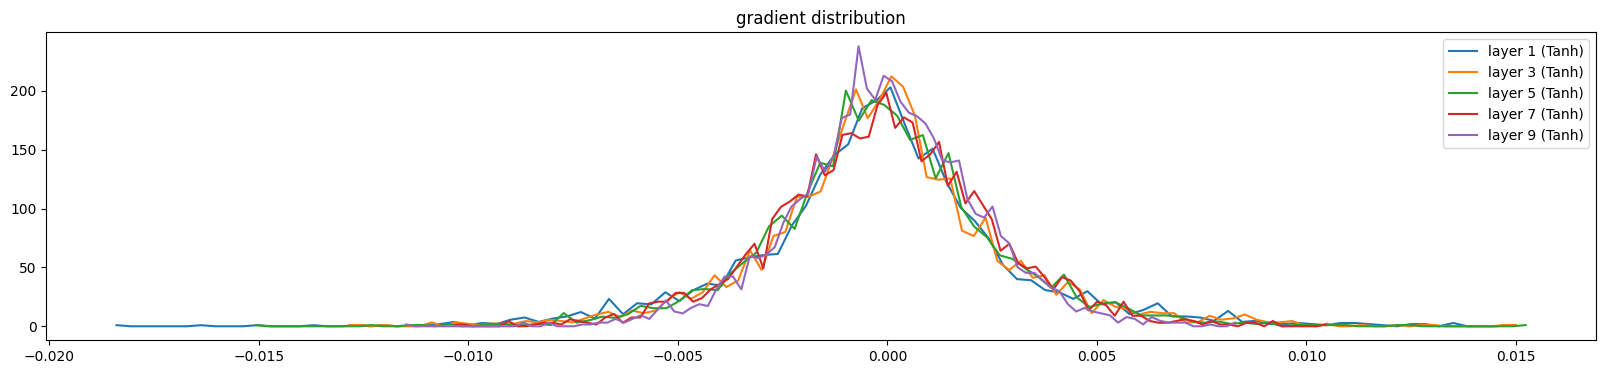

In [49]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
        
plt.legend(legends)
plt.title('gradient distribution')
    

weight   (27, 10) | mean +0.000168 | std 1.138394e-02 | grad:data ratio 1.139587e-02
weight  (60, 100) | mean +0.000078 | std 9.648364e-03 | grad:data ratio 4.369683e-02
weight (100, 100) | mean -0.000031 | std 7.571717e-03 | grad:data ratio 4.522583e-02
weight (100, 100) | mean +0.000014 | std 6.579550e-03 | grad:data ratio 3.951645e-02
weight (100, 100) | mean -0.000059 | std 5.740596e-03 | grad:data ratio 3.425079e-02
weight (100, 100) | mean -0.000010 | std 5.153101e-03 | grad:data ratio 3.050941e-02
weight  (100, 27) | mean +0.000000 | std 2.366471e-02 | grad:data ratio 3.673902e-01


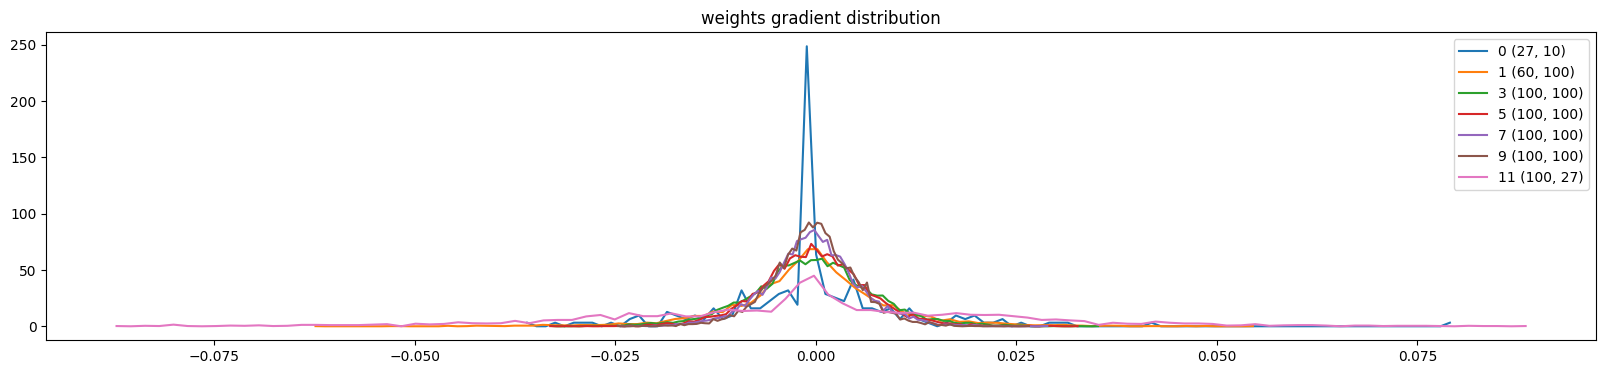

In [50]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # weight matrix only - ignore bias
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

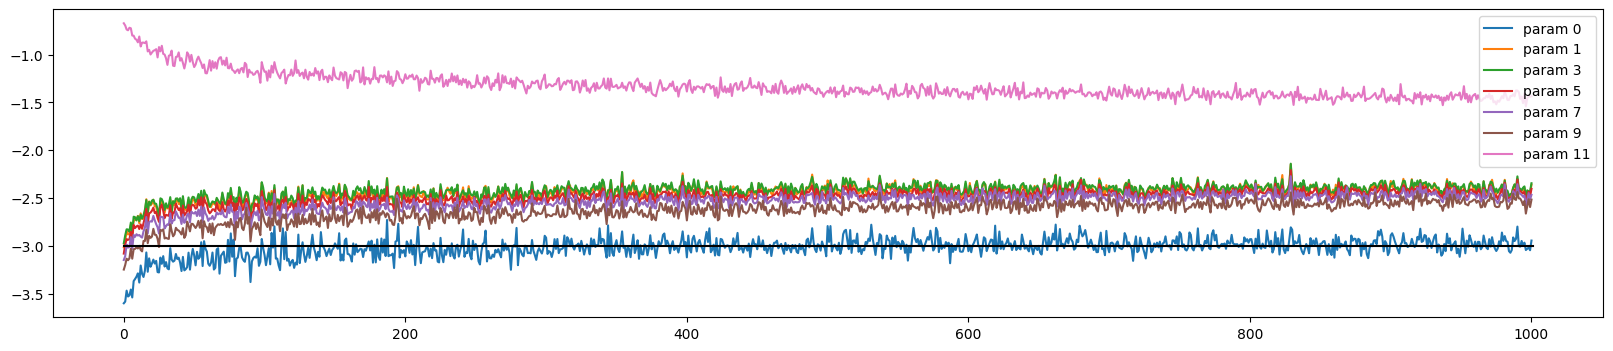

In [51]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


# Use batch norm to reduce calibration burden

In [54]:
layers = [
    Linear(n_embed * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),           BatchNorm1d(vocab_size),
]


with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1

    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True


max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    xb, yb = Xtr[ix], Ytr[ix]

    emb = C[xb]
    x = emb.view(-1, block_size*n_embed)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)


    #back pass
    for layer in layers:
        layer.out.retain_grad() # retain grad for tanh
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())    

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break    

50551
      0/ 200000: 3.2883


layer 2 (      Tanh): mean +0.00, std 0.62, saturated: 3.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.22%
layer 8 (      Tanh): mean +0.01, std 0.64, saturated: 1.91%
layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.00%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.94%


Text(0.5, 1.0, 'activation distribution')

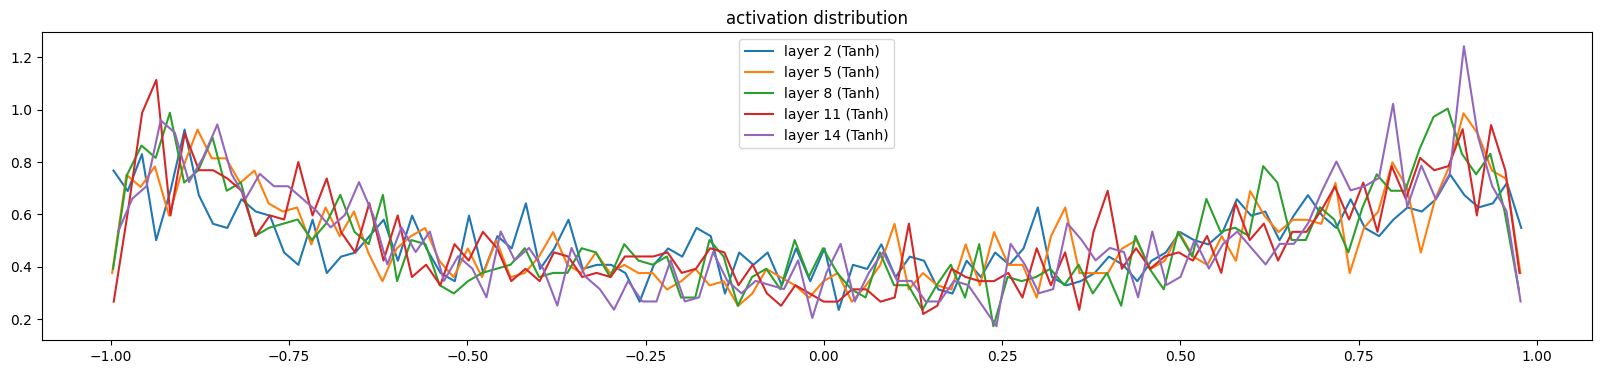

In [55]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
        
plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): mean +0.00, std 0.00
layer 5 (      Tanh): mean +0.00, std 0.00
layer 8 (      Tanh): mean -0.00, std 0.00
layer 11 (      Tanh): mean +0.00, std 0.00
layer 14 (      Tanh): mean +0.00, std 0.00


Text(0.5, 1.0, 'gradient distribution')

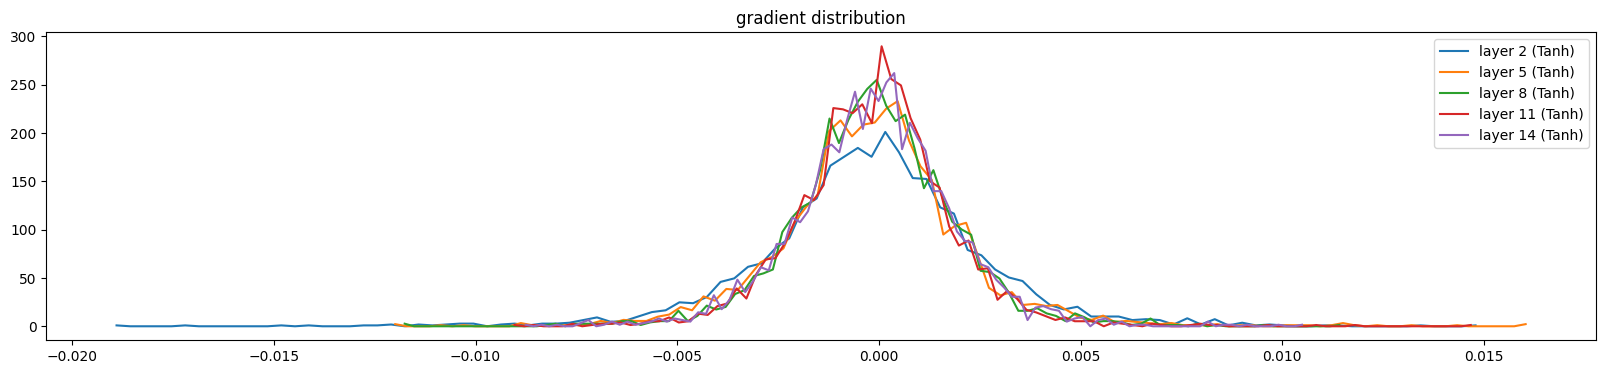

In [56]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
        
plt.legend(legends)
plt.title('gradient distribution')


weight   (27, 10) | mean -0.000000 | std 1.013303e-02 | grad:data ratio 1.014123e-02
weight  (60, 100) | mean -0.000228 | std 1.126206e-02 | grad:data ratio 8.545115e-02
weight (100, 100) | mean -0.000067 | std 8.458823e-03 | grad:data ratio 8.340642e-02
weight (100, 100) | mean +0.000020 | std 7.462138e-03 | grad:data ratio 7.384604e-02
weight (100, 100) | mean +0.000033 | std 6.089953e-03 | grad:data ratio 6.026702e-02
weight (100, 100) | mean +0.000001 | std 5.955040e-03 | grad:data ratio 5.874918e-02
weight  (100, 27) | mean +0.000027 | std 1.130037e-02 | grad:data ratio 1.096039e-01


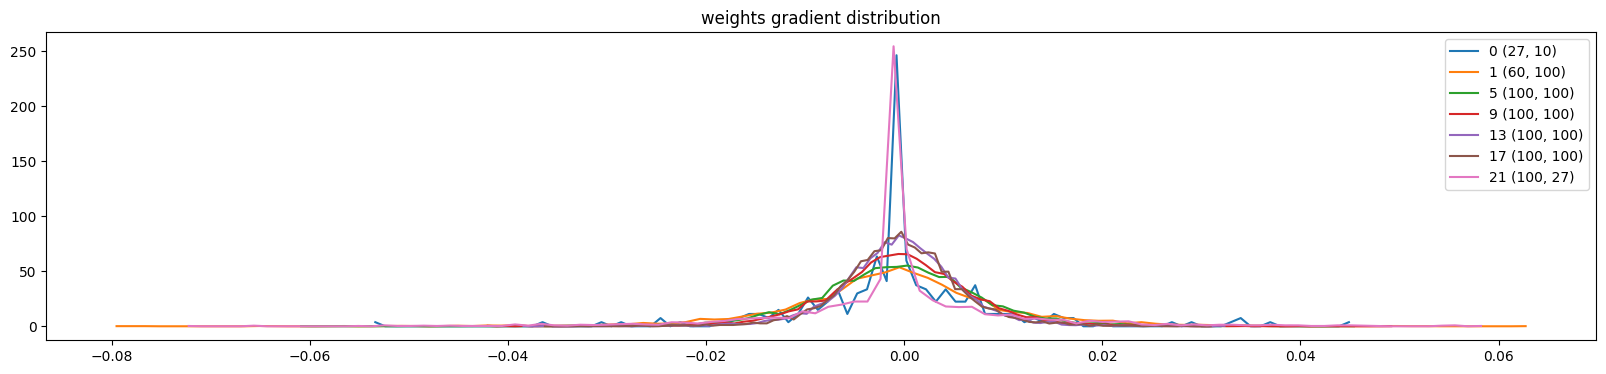

In [57]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # weight matrix only - ignore bias
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

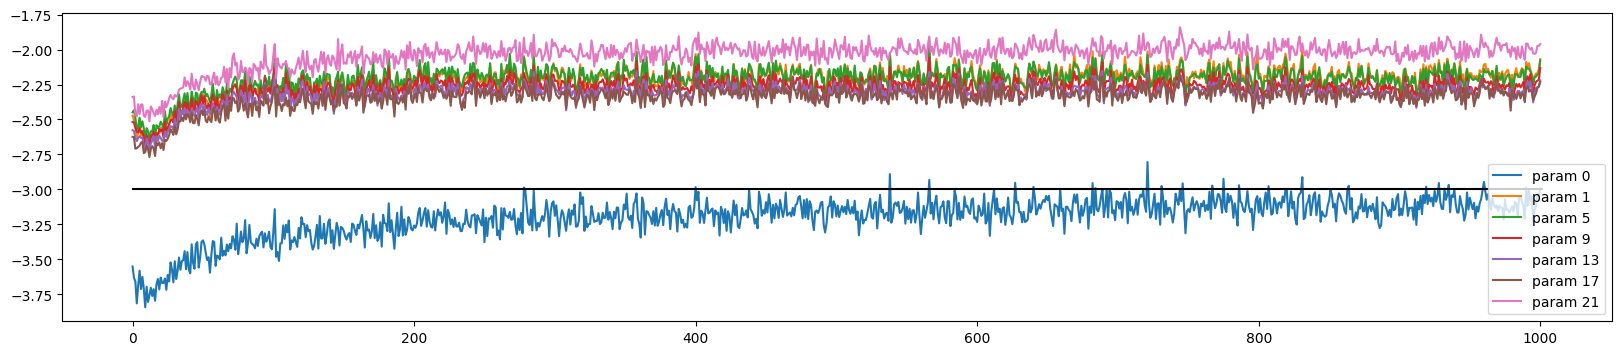

In [58]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
